## Importing Libraries and Setting Up

In [ ]:
# Install & import libraries
!pip install -q tensorflow-datasets
import tensorflow_datasets as tfds
import tensorflow as tf

# Force GPU
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Load with proper splits
(train_ds, val_ds, test_ds), info = tfds.load(
    'cassava',
    split=['train', 'validation', 'test'],
    with_info=True,
    as_supervised=True
)

print("✅ Dataset loaded!")
print("Number of classes:", info.features['label'].num_classes)
print("Class names:", info.features['label'].names)
print("Train size:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val size:", tf.data.experimental.cardinality(val_ds).numpy())

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cassava/incomplete.ZN8L71_0.1.0/cassava-test.tfrecord*...:   0%|          …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cassava/incomplete.ZN8L71_0.1.0/cassava-validation.tfrecord*...:   0%|    …

Dataset cassava downloaded and prepared to /root/tensorflow_datasets/cassava/0.1.0. Subsequent calls will reuse this data.
✅ Dataset loaded!
Number of classes: 5
Class names: ['cbb', 'cbsd', 'cgm', 'cmd', 'healthy']
Train size: 5656
Val size: 1889


## Viewing Some Sample Images from the Dataset

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# View Sample Images
plt.figure(figsize=(12, 12))
for i, (image, label) in enumerate(train_ds.take(9)):
    plt.subplot(3, 3, i+1)
    plt.imshow(image.numpy())
    plt.title(info.features['label'].names[label.numpy()], fontsize=11)
    plt.axis('off')
plt.suptitle("Sample Cassava Leaf Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# View Class Distribution
class_names = info.features['label'].names
label_counts = np.zeros(len(class_names), dtype=int)

for _, label in train_ds:
    label_counts[label.numpy()] += 1

plt.figure(figsize=(10, 5))
bars = plt.bar(class_names, label_counts, color='seagreen', edgecolor='black')
plt.title("Class Distribution in Training Set", fontsize=13, fontweight='bold')
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15, ha='right')

# Add count labels on top of each bar
for bar, count in zip(bars, label_counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20,
             str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("EDA complete!")
print("\nClass distribution:")
for name, count in zip(class_names, label_counts):
    print(f"  {name}: {count} images ({count/label_counts.sum()*100:.1f}%)")

Output hidden; open in https://colab.research.google.com to view.

## Data Preprocessing

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 16  # Safe for T4 + MobileNetV2

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    return image, label

# Augment THEN preprocess
train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Preprocessing complete!")
print(f"Batch size: {BATCH_SIZE} | Image size: {IMG_SIZE}x{IMG_SIZE}")
print("Train: augmented + preprocessed")
print("Val/Test: preprocessed only")

Preprocessing complete!
Batch size: 16 | Image size: 224x224
Train: augmented + preprocessed
Val/Test: preprocessed only


## Training and Building the Model

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from google.colab import drive

# Mount Google Drive so it can protect my model from session crashes
drive.mount('/content/drive')

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# Custom classification head
x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
predictions = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ModelCheckpoint(
        '/content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

print("MobileNetV2 model built!")
model.summary()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MobileNetV2 model built!


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,269,509 (8.66 MB)

 Trainable params: 8,965 (35.02 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

### Model Training

In [ ]:
import numpy as np

# Compute class weights from EDA label counts
NUM_CLASSES = info.features['label'].num_classes
label_counts_array = np.array(label_counts)
total = label_counts_array.sum()

class_weights = {
    i: np.log1p(total / (NUM_CLASSES * count))
    for i, count in enumerate(label_counts_array)
}

print("Class weights applied:")
for i, (name, weight) in enumerate(zip(info.features['label'].names, class_weights.values())):
    print(f"  {name}: {weight:.3f}")

# ── Training ───────────────────────────────────────────────────────
print("\n Starting training on MobileNetV2... (15 epochs max)")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

print("\n Training finished!")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]*100:.1f}%")
print(f"Best validation accuracy:  {max(history.history['val_accuracy'])*100:.1f}%")
print(" Best model saved to Google")

Class weights applied:
  cbb: 1.232
  cbsd: 0.579
  cgm: 0.902
  cmd: 0.355
  healthy: 1.522

 Starting training on MobileNetV2... (15 epochs max)
Epoch 1/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.4336 - loss: 1.0191
Epoch 1: val_accuracy improved from None to 0.67390, saving model to /content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5
354/354 ━━━━━━━━━━━━━━━━━━━━ 104s 233ms/step - accuracy: 0.5182 - loss: 0.8811 - val_accuracy: 0.6739 - val_loss: 0.8720 - learning_rate: 0.0010
Epoch 2/15
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.6093 - loss: 0.7176
Epoch 2: val_accuracy improved from 0.67390 to 0.69508, saving model to /content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5
354/354 ━━━━━━━━━━━━━━━━━━━━ 54s 152ms/step - accuracy: 0.6172 - loss: 0.7006 - val_accuracy: 0.6951 - val_loss: 0.8502 - learning_rate: 0.0010
Epoch 3/15
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.6266 - loss: 0.6762
Epoch 3: val_accuracy did not improve from 0.69508
354/354 ━━━━━━━━━━━━━━━━━━━━ 56s 158ms/step - accuracy: 0.6337 - loss: 0.6528 - val_accuracy: 0.6840 - val_loss: 0.8519 - learning_rate: 0.0010
Epoch 4/15
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.6555 - loss: 0.6236
Epoch 4: val_accuracy improved from 0.69508 to 0.70672, saving model to /content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5
354/354 ━━━━━━━━━━━━━━━━━━━━ 53s 150ms/step - accuracy: 0.6510 - loss: 0.6128 - val_accuracy: 0.7067 - val_loss: 0.8157 - learning_rate: 0.0010
Epoch 5/15
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.6714 - loss: 0.6159
Epoch 5: val_accuracy did not improve from 0.70672
354/354 ━━━━━━━━━━━━━━━━━━━━ 53s 149ms/step - accuracy: 0.6733 - loss: 0.5883 - val_accuracy: 0.6893 - val_loss: 0.8477 - learning_rate: 0.0010
Epoch 6/15
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.6724 - loss: 0.6135
Epoch 6: val_accuracy improved from 0.70672 to 0.71678, saving model to /content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5



Epoch 6: finished saving model to /content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5
354/354 ━━━━━━━━━━━━━━━━━━━━ 57s 161ms/step - accuracy: 0.6687 - loss: 0.5857 - val_accuracy: 0.7168 - val_loss: 0.8083 - learning_rate: 0.0010
Epoch 7/15
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.6804 - loss: 0.5965
Epoch 7: val_accuracy did not improve from 0.71678
354/354 ━━━━━━━━━━━━━━━━━━━━ 51s 144ms/step - accuracy: 0.6818 - loss: 0.5732 - val_accuracy: 0.7009 - val_loss: 0.8188 - learning_rate: 0.0010
Epoch 8/15
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.6677 - loss: 0.5894
Epoch 8: val_accuracy did not improve from 0.71678
354/354 ━━━━━━━━━━━━━━━━━━━━ 87s 159ms/step - accuracy: 0.6708 - loss: 0.5683 - val_accuracy: 0.7115 - val_loss: 0.8056 - learning_rate: 0.0010
Epoch 9/15
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.6719 - loss: 0.5890
Epoch 9: val_accuracy did not improve from 0.71678
354/354 ━━━━━━━━━━━━━━━━━━━━ 77s 145ms/step - accura


Epoch 10: finished saving model to /content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
354/354 ━━━━━━━━━━━━━━━━━━━━ 57s 162ms/step - accuracy: 0.6736 - loss: 0.5733 - val_accuracy: 0.7184 - val_loss: 0.8061 - learning_rate: 0.0010
Epoch 11/15
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.6827 - loss: 0.5579
Epoch 11: val_accuracy did not improve from 0.71837
354/354 ━━━━━━━━━━━━━━━━━━━━ 57s 160ms/step - accuracy: 0.6895 - loss: 0.5263 - val_accuracy: 0.7157 - val_loss: 0.7979 - learning_rate: 5.0000e-04
Epoch 12/15
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.6928 - loss: 0.5567
Epoch 12: val_accuracy improved from 0.71837 to 0.72472, saving model to /content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5



Epoch 12: finished saving model to /content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5
354/354 ━━━━━━━━━━━━━━━━━━━━ 54s 153ms/step - accuracy: 0.6929 - loss: 0.5318 - val_accuracy: 0.7247 - val_loss: 0.7820 - learning_rate: 5.0000e-04
Epoch 13/15
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.6836 - loss: 0.5528
Epoch 13: val_accuracy did not improve from 0.72472
354/354 ━━━━━━━━━━━━━━━━━━━━ 57s 161ms/step - accuracy: 0.6883 - loss: 0.5249 - val_accuracy: 0.7237 - val_loss: 0.7856 - learning_rate: 5.0000e-04
Epoch 14/15
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.6885 - loss: 0.5488
Epoch 14: val_accuracy did not improve from 0.72472

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
354/354 ━━━━━━━━━━━━━━━━━━━━ 52s 147ms/step - accuracy: 0.6924 - loss: 0.5283 - val_accuracy: 0.7210 - val_loss: 0.7935 - learning_rate: 5.0000e-04
Epoch 15/15
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.6984 - loss: 0.5329
Epoch 1


Epoch 15: finished saving model to /content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5
354/354 ━━━━━━━━━━━━━━━━━━━━ 55s 154ms/step - accuracy: 0.7042 - loss: 0.5049 - val_accuracy: 0.7321 - val_loss: 0.7776 - learning_rate: 2.5000e-04

 Training finished!
Final validation accuracy: 73.2%
Best validation accuracy:  73.2%
 Best model saved to Google


### Fine-tuning the Model

In [8]:
# Fine-tuning
print("Unfreezing top 30 layers of MobileNetV2...")

base_model.trainable = True

# Freeze everything except last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Verify the layers that have been frozen
trainable_count = sum([1 for l in base_model.layers if l.trainable])
print(f"Trainable layers in base model: {trainable_count}")

# Recompile at very low learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        '/content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]

print("Starting Phase 2 fine-tuning (10 epochs max)...")

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks_ft
)

print("\n Fine-tuning complete!")
print(f"Phase 1 best: 73.2%")
print(f"Phase 2 best: {max(history_ft.history['val_accuracy'])*100:.1f}%")
print(f"Improvement:  +{(max(history_ft.history['val_accuracy']) - 0.732)*100:.1f}%")

Unfreezing top 30 layers of MobileNetV2...
Trainable layers in base model: 30
Starting Phase 2 fine-tuning (10 epochs max)...
Epoch 1/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.7090 - loss: 0.5137
Epoch 1: val_accuracy improved from None to 0.75331, saving model to /content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5
354/354 ━━━━━━━━━━━━━━━━━━━━ 105s 216ms/step - accuracy: 0.7123 - loss: 0.4994 - val_accuracy: 0.7533 - val_loss: 0.7209 - learning_rate: 1.0000e-05
Epoch 2/10
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.7199 - loss: 0.4777
Epoch 2: val_accuracy did not improve from 0.75331
354/354 ━━━━━━━━━━━━━━━━━━━━ 56s 157ms/step - accuracy: 0.7242 - loss: 0.4592 - val_accuracy: 0.7470 - val_loss: 0.7305 - learning_rate: 1.0000e-05
Epoch 3/10
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7232 - loss: 0.4571
Epoch 3: val_accuracy did not improve from 0.75331

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
354/354 ━━━━━━━━━━━━━━━━━━━━ 56s 158ms/step - accuracy: 0.7353 - loss: 0.4343 - val_accuracy: 0.7459 - val_loss: 0.7224 - learning_rate: 1.0000e-05
Epoch 4/10
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7483 - loss: 0.4318
Epoch 4: val_

In [10]:
# Load the best saved model from Drive
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5'
)

# Find MobileNetV2 base model by name instead of index
base_model = None
for layer in model.layers:
    if 'mobilenetv2' in layer.name.lower():
        base_model = layer
        break

if base_model is None:
    # Print all layer names so we can find the right one
    print("MobileNetV2 not found. All layers:")
    for i, layer in enumerate(model.layers):
        print(f"  [{i}] {layer.name} — {type(layer).__name__}")
else:
    print("Model loaded from Drive")
    print(f"Base model name: {base_model.name}")
    print(f"Total layers in base: {len(base_model.layers)}")

MobileNetV2 not found. All layers:
  [0] input_layer_1 — InputLayer
  [1] Conv1 — Conv2D
  [2] bn_Conv1 — BatchNormalization
  [3] Conv1_relu — ReLU
  [4] expanded_conv_depthwise — DepthwiseConv2D
  [5] expanded_conv_depthwise_BN — BatchNormalization
  [6] expanded_conv_depthwise_relu — ReLU
  [7] expanded_conv_project — Conv2D
  [8] expanded_conv_project_BN — BatchNormalization
  [9] block_1_expand — Conv2D
  [10] block_1_expand_BN — BatchNormalization
  [11] block_1_expand_relu — ReLU
  [12] block_1_pad — ZeroPadding2D
  [13] block_1_depthwise — DepthwiseConv2D
  [14] block_1_depthwise_BN — BatchNormalization
  [15] block_1_depthwise_relu — ReLU
  [16] block_1_project — Conv2D
  [17] block_1_project_BN — BatchNormalization
  [18] block_2_expand — Conv2D
  [19] block_2_expand_BN — BatchNormalization
  [20] block_2_expand_relu — ReLU
  [21] block_2_depthwise — DepthwiseConv2D
  [22] block_2_depthwise_BN — BatchNormalization
  [23] block_2_depthwise_relu — ReLU
  [24] block_2_project — 

In [11]:
# Freeze all layers first
for layer in model.layers:
    layer.trainable = False

# Unfreeze last 30 layers
for layer in model.layers[-30:]:
    layer.trainable = True

trainable_count = sum([1 for l in model.layers if l.trainable])
print(f" Trainable layers: {trainable_count} of {len(model.layers)}")

# Recompile at very low learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        '/content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]

print("Starting clean Phase 2 fine-tuning...")

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks_ft
)

print("\n Fine-tuning complete!")
print(f"Previous best: 75.3%")
print(f"New best: {max(history_ft.history['val_accuracy'])*100:.1f}%")

 Trainable layers: 30 of 158
Starting clean Phase 2 fine-tuning...
Epoch 1/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.7315 - loss: 0.4800
Epoch 1: val_accuracy improved from None to 0.74590, saving model to /content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5
354/354 ━━━━━━━━━━━━━━━━━━━━ 86s 197ms/step - accuracy: 0.7300 - loss: 0.4626 - val_accuracy: 0.7459 - val_loss: 0.7308 - learning_rate: 1.0000e-05
Epoch 2/10
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7417 - loss: 0.4611
Epoch 2: val_accuracy improved from 0.74590 to 0.75013, saving model to /content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Hackathon/best_cassavaguard_mobilenet.h5
354/354 ━━━━━━━━━━━━━━━━━━━━ 55s 156ms/step - accuracy: 0.7433 - loss: 0.4388 - val_accuracy: 0.7501 - val_loss: 0.7311 - learning_rate: 1.0000e-05
Epoch 3/10
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.7519 - loss: 0.4243
Epoch 3: val_accuracy did not improve from 0.75013

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
354/354 ━━━━━━━━━━━━━━━━━━━━ 57s 162ms/step - accuracy: 0.7477 - loss: 0.4140 - val_accuracy: 0.7480 - val_loss: 0.7419 - learning_rate: 1.0000e-05
Epoch 4/10
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.7514 - loss: 0.3963
Epoch 4: val_accuracy did not improve from 0.75013
354/354 ━━━━━━━━━━━━━━━━━━━━ 55s 154ms/step - accuracy: 0.7539 - loss: 0.3949 - val_accuracy: 0.7485 - val_loss: 0.7337 - learning_rate: 5.0000e-06
Epoch 5/10
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.7705 - loss: 0.3915
Epoch 5: val_a

## Model Evaluation

Classification Report:
              precision    recall  f1-score   support

         cbb       0.48      0.54      0.51       155
        cbsd       0.72      0.72      0.72       481
         cgm       0.68      0.60      0.64       258
         cmd       0.88      0.86      0.87       886
     healthy       0.61      0.79      0.69       105

    accuracy                           0.76      1885
   macro avg       0.67      0.70      0.68      1885
weighted avg       0.76      0.76      0.76      1885



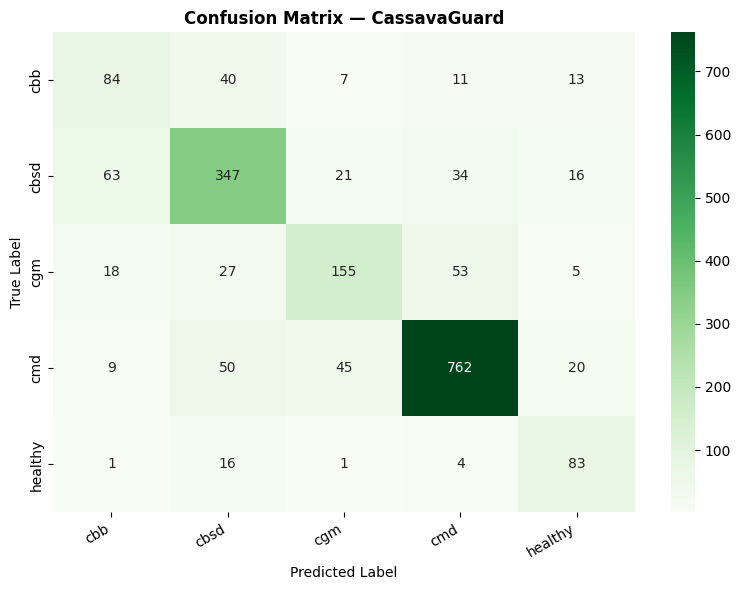


 Test Accuracy: 75.9%


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions on test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names = info.features['label'].names

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix — CassavaGuard', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

test_acc = np.mean(y_true == y_pred)
print(f"\n Test Accuracy: {test_acc*100:.1f}%")

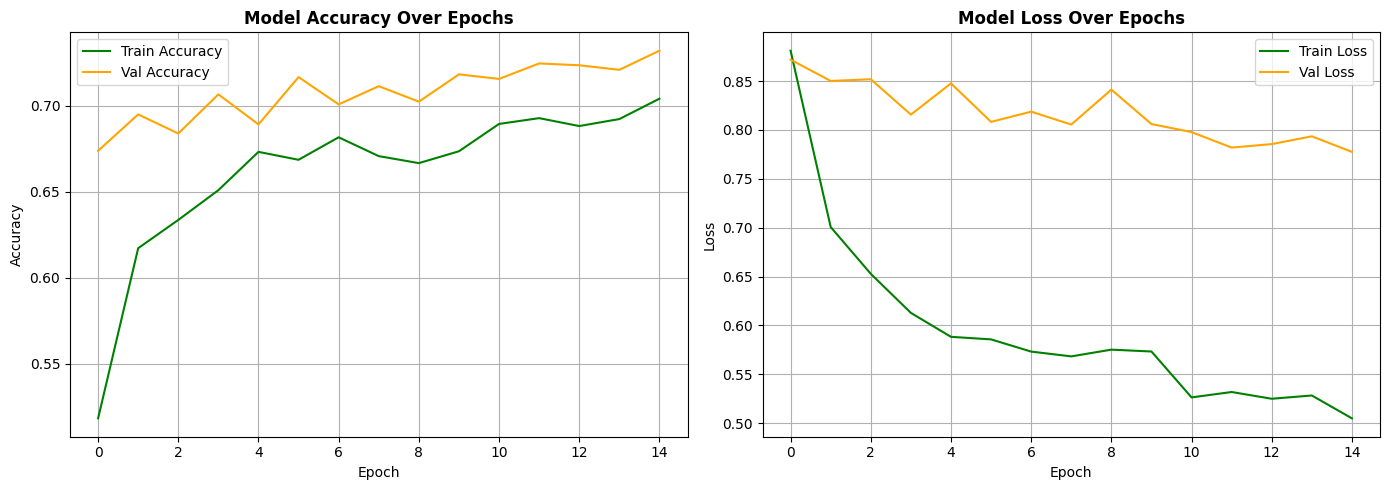

Evaluation complete. Plots saved to Drive.

 Ready to build the app.


In [13]:
# Save training plots to Drive
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='green')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
ax1.set_title('Model Accuracy Over Epochs', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Train Loss', color='green')
ax2.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax2.set_title('Model Loss Over Epochs', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Hackathon/training_plots.png', dpi=150)
plt.show()

print("Evaluation complete. Plots saved to Drive.")
print("\n Ready to build the app.")

## Model Deployment

In [15]:
app_code = """
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

model = tf.keras.models.load_model('best_cassavaguard_mobilenet.h5')

CLASS_NAMES = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']

DISEASE_INFO = {
    'CBB': {
        'full_name': 'Cassava Bacteria Blight',
        'symptoms': 'Angular leaf spots, wilting, and stem dieback.',
        'action': 'Remove and destroy infected plants. Avoid working in fields when wet.'
    },
    'CBSD': {
        'full_name': 'Cassava Brown Streak Disease',
        'symptoms': 'Yellow patches on leaves, brown streaks inside the root.',
        'action': 'Use certified clean planting material. Destroy infected crops immediately.'
    },
    'CGM': {
        'full_name': 'Cassava Green Mottle',
        'symptoms': 'Mottled yellowing and distorted leaves.',
        'action': 'Use resistant varieties. Control whitefly populations.'
    },
    'CMD': {
        'full_name': 'Cassava Mosaic Disease',
        'symptoms': 'Mosaic yellowing, distorted and twisted leaves.',
        'action': 'Plant CMD-resistant varieties. Remove and burn infected plants.'
    },
    'Healthy': {
        'full_name': 'Healthy Plant',
        'symptoms': 'No disease detected.',
        'action': 'Your cassava plant appears healthy. Continue normal farming practices.'
    }
}

def predict(image):
    img = Image.fromarray(image).resize((224, 224))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    predictions = model.predict(img_array, verbose=0)[0]
    top_class = CLASS_NAMES[np.argmax(predictions)]
    confidence = float(np.max(predictions))
    info = DISEASE_INFO[top_class]
    result = f'''
## { if top_class == 'Healthy' else 'Beware'} {info['full_name']}
**Confidence:** {confidence*100:.1f}%
**Symptoms:** {info['symptoms']}
**Recommended Action:** {info['action']}
---
*CassavaGuard — Built for African smallholder farmers*
    '''
    label_scores = {CLASS_NAMES[i]: float(predictions[i]) for i in range(5)}
    return label_scores, result

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown('''
    # CassavaGuard — Cassava Disease Detector
    ### AI-powered crop disease diagnosis for African farmers
    Upload a photo of a cassava leaf to get an instant diagnosis.
    Built on real field images from African farms.
    ''')
    with gr.Row():
        with gr.Column():
            image_input = gr.Image(label="Upload Cassava Leaf Photo")
            submit_btn = gr.Button("Diagnose", variant="primary")
        with gr.Column():
            label_output = gr.Label(num_top_classes=5, label="Disease Probability")
            result_output = gr.Markdown(label="Diagnosis & Action")
    submit_btn.click(fn=predict, inputs=image_input, outputs=[label_output, result_output])
    gr.Markdown('''
    ### Disease Classes
    | Code | Full Name |
    |---|---|
    | CBB | Cassava Bacteria Blight |
    | CBSD | Cassava Brown Streak Disease |
    | CGM | Cassava Green Mottle |
    | CMD | Cassava Mosaic Disease |
    | — | Healthy |
    ''')

demo.launch()
"""

reqs = """tensorflow==2.15.0
gradio
numpy
Pillow"""

with open('/content/drive/MyDrive/Hackathon/app.py', 'w') as f:
    f.write(app_code)

with open('/content/drive/MyDrive/Hackathon/requirements.txt', 'w') as f:
    f.write(reqs)

print("app.py and requirements.txt saved to Drive")

app.py and requirements.txt saved to Drive
